In [16]:
import mitsuba as mi
import datautils as dp

In [17]:
mi.variants()

['scalar_rgb',
 'scalar_spectral',
 'scalar_spectral_polarized',
 'llvm_ad_rgb',
 'llvm_ad_mono',
 'llvm_ad_mono_polarized',
 'llvm_ad_spectral',
 'llvm_ad_spectral_polarized']

In [18]:
mi.set_variant("llvm_ad_spectral")

In [19]:
scene = mi.load_file("./scenes/simple.xml")

In [20]:
image = mi.render(scene, spp=256)

In [21]:
type(image)

drjit.llvm.ad.TensorXf

In [22]:
mi.Bitmap(image)

Bitmap[
  pixel_format = rgb,
  component_format = float32,
  size = [256, 256],
  srgb_gamma = 0,
  struct = Struct<12>[
    float32 R; // @0, premultiplied alpha
    float32 G; // @4, premultiplied alpha
    float32 B; // @8, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

In [23]:
cam2 = mi.load_dict({
    "type": "perspective",
    'to_world': mi.ScalarTransform4f.look_at(
        origin=[0, 0, 1],
        target=[0, 0, 0],
        up=[0, 1, 0]
    ),
    'film': {
        'type': 'hdrfilm',
        'width': 512,
        'height': 512}
})

In [24]:
image2 = mi.render(scene, sensor=cam2, spp=256)

In [25]:
mi.Bitmap(image2)

Bitmap[
  pixel_format = rgb,
  component_format = float32,
  size = [512, 512],
  srgb_gamma = 0,
  struct = Struct<12>[
    float32 R; // @0, premultiplied alpha
    float32 G; // @4, premultiplied alpha
    float32 B; // @8, premultiplied alpha
  ],
  data = [ 3 MiB of image data ]
]

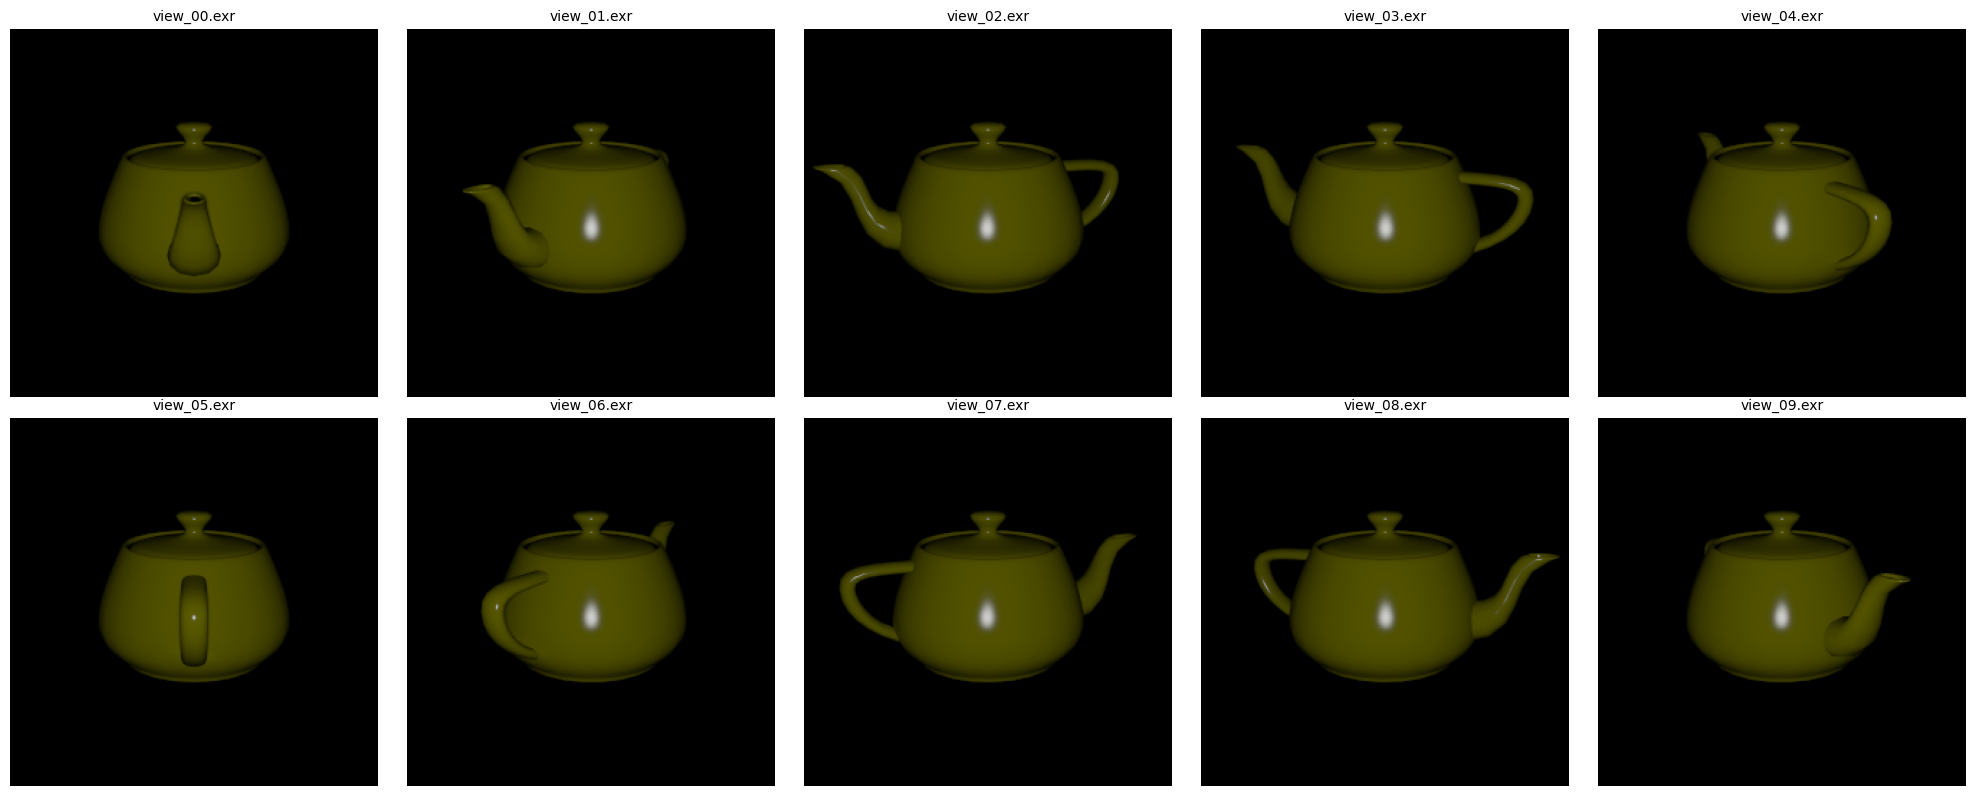

Showing 10 file(s) from: /Users/27171653/Desktop/PhD/3dRender/views


['views/view_00.exr',
 'views/view_01.exr',
 'views/view_02.exr',
 'views/view_03.exr',
 'views/view_04.exr',
 'views/view_05.exr',
 'views/view_06.exr',
 'views/view_07.exr',
 'views/view_08.exr',
 'views/view_09.exr']

In [26]:
dp.view_mitsuba_renders_mi_bitmap(folder="./views", pattern="view_*.exr")


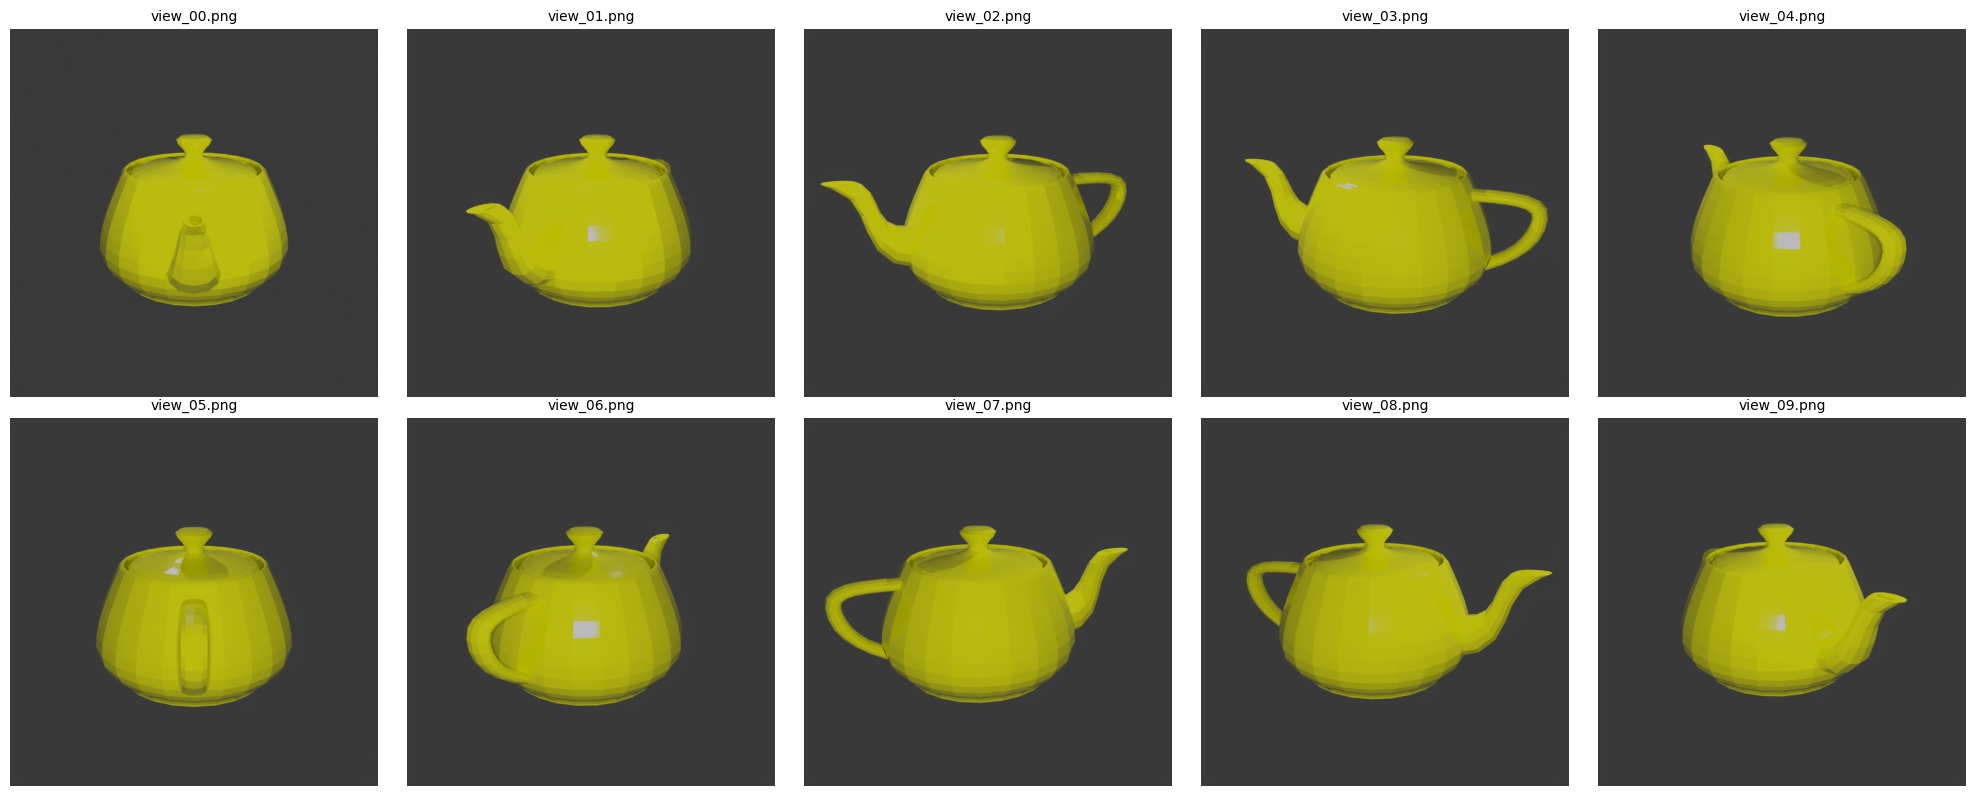

Showing 10 file(s) from: /Users/27171653/Desktop/PhD/3dRender/renders


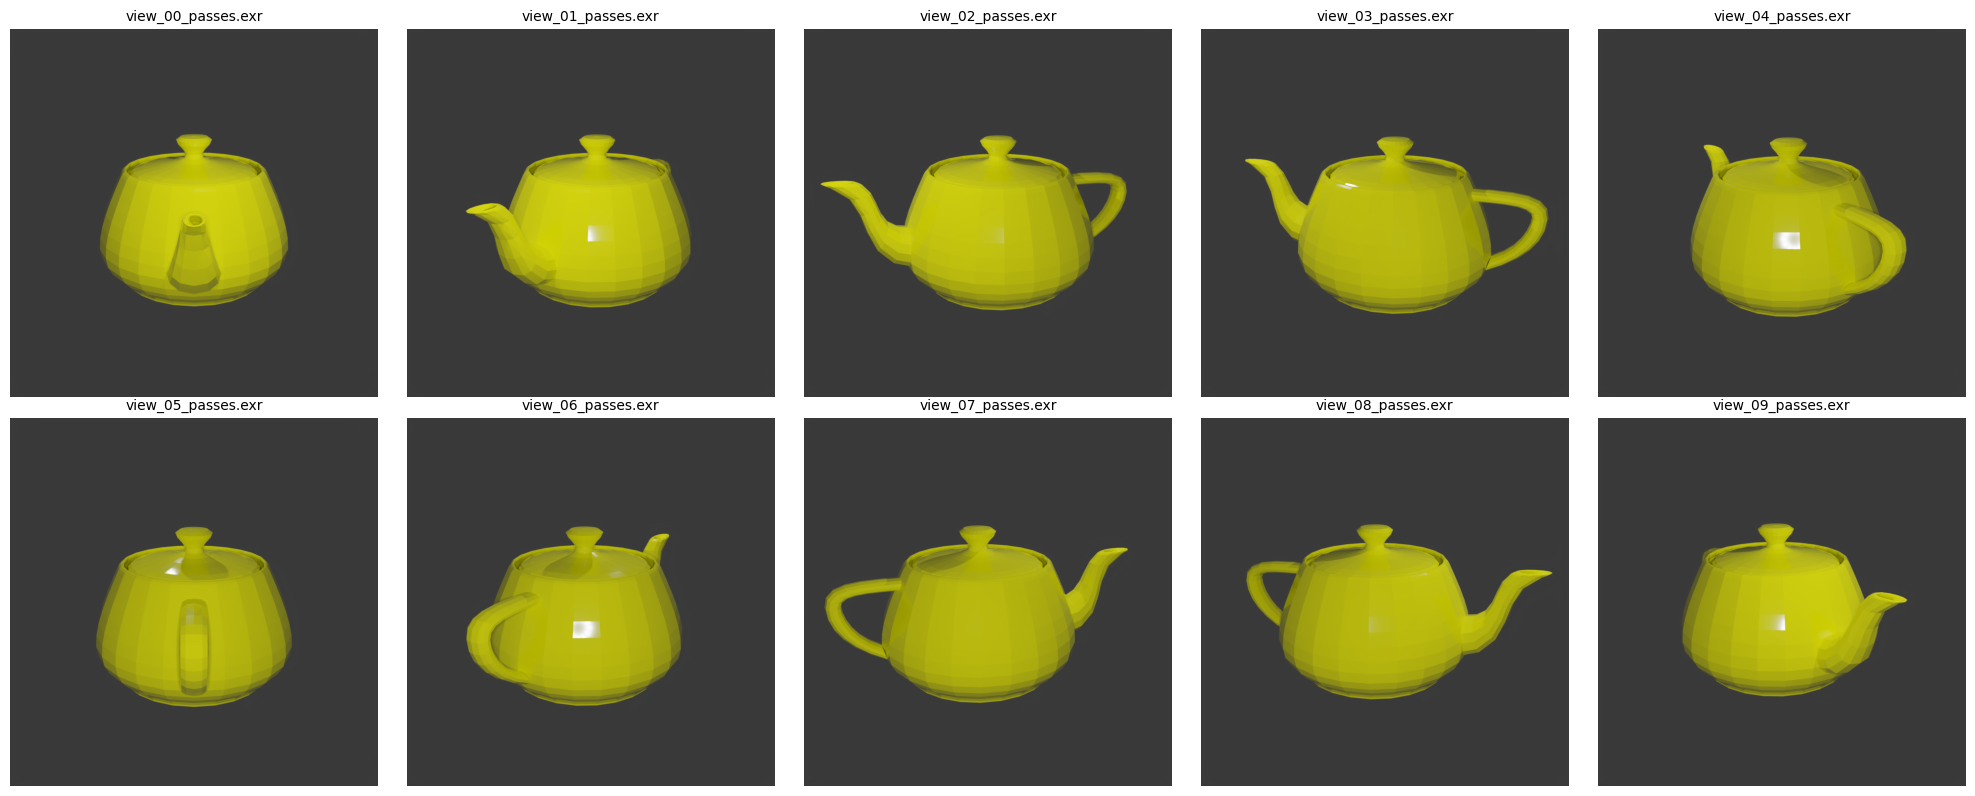

Showing 10 file(s) from: /Users/27171653/Desktop/PhD/3dRender/renders


['renders/view_00_passes.exr',
 'renders/view_01_passes.exr',
 'renders/view_02_passes.exr',
 'renders/view_03_passes.exr',
 'renders/view_04_passes.exr',
 'renders/view_05_passes.exr',
 'renders/view_06_passes.exr',
 'renders/view_07_passes.exr',
 'renders/view_08_passes.exr',
 'renders/view_09_passes.exr']

In [27]:
dp.view_blender_renders("./renders", "view_*.png")
dp.view_blender_renders("./renders", "view_*_passes.exr", print_exr_channels=False, exr_layer_hint="auto")

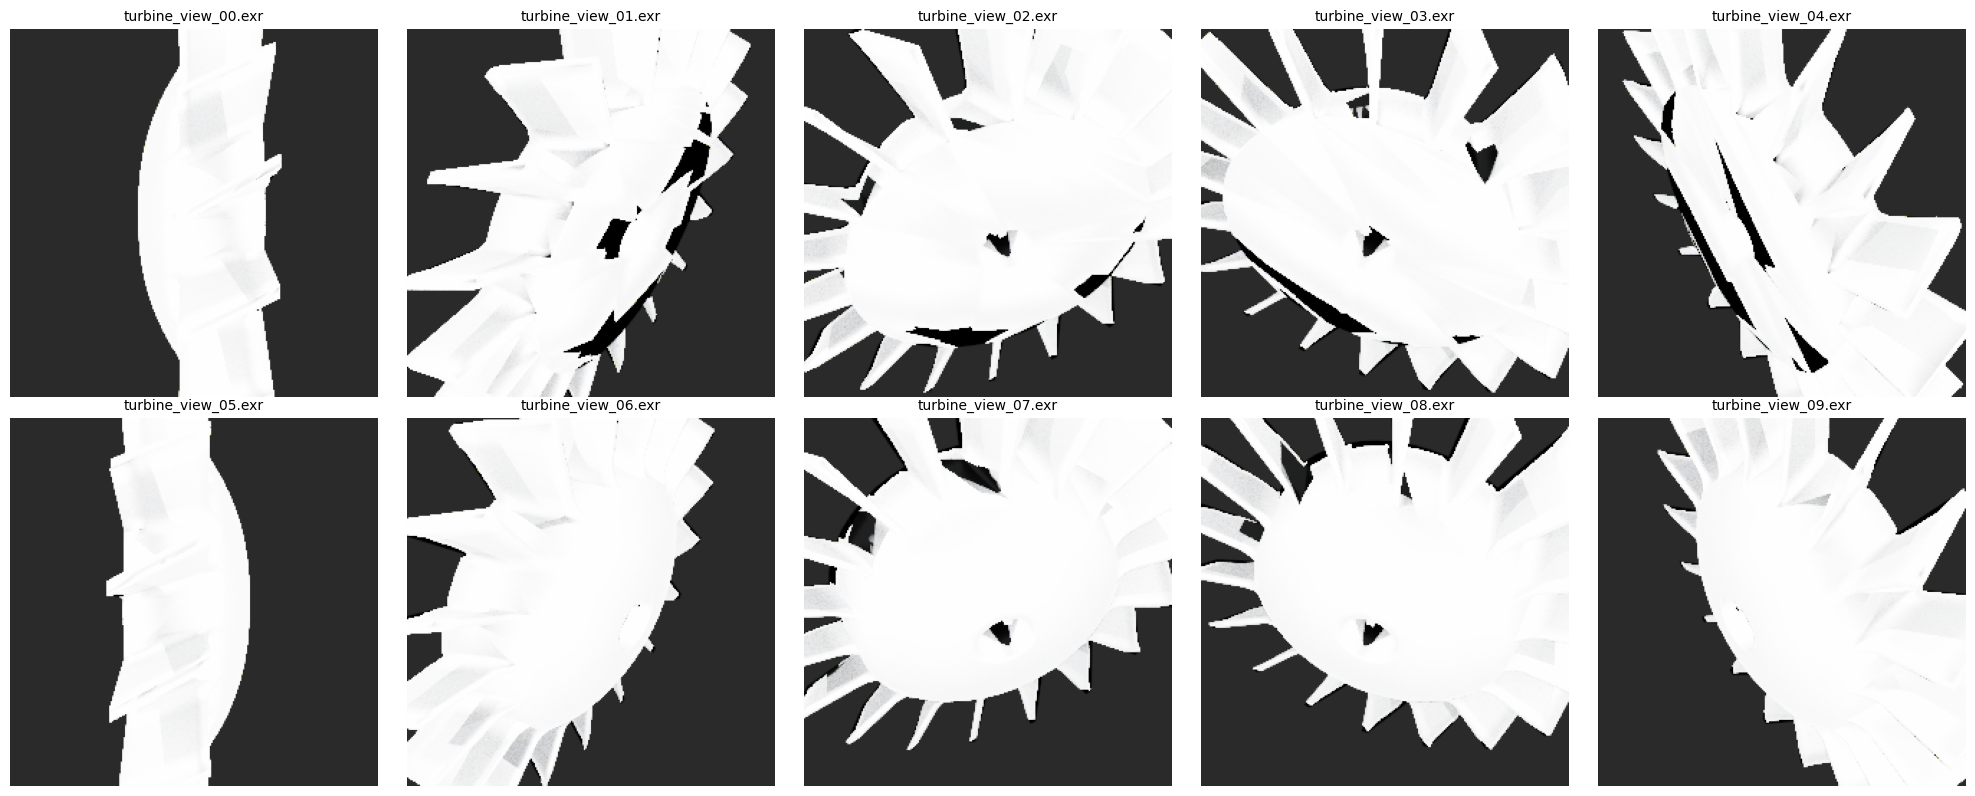

Showing 10 file(s) from: /Users/27171653/Desktop/PhD/3dRender/views/turbine


['views/turbine/turbine_view_00.exr',
 'views/turbine/turbine_view_01.exr',
 'views/turbine/turbine_view_02.exr',
 'views/turbine/turbine_view_03.exr',
 'views/turbine/turbine_view_04.exr',
 'views/turbine/turbine_view_05.exr',
 'views/turbine/turbine_view_06.exr',
 'views/turbine/turbine_view_07.exr',
 'views/turbine/turbine_view_08.exr',
 'views/turbine/turbine_view_09.exr']

In [28]:
dp.view_mitsuba_renders_mi_bitmap(folder="./views/turbine", pattern="turbine_view_*.exr")